In [1]:
import os
import glob
import cv2
import numpy as np
from sklearn.cluster import MiniBatchKMeans
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, normalize
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt

In [15]:
# -------- CONFIGURATION ----------
DATA_DIR = "flowers"               # structure: data/<class>/*.jpg
IMAGE_MAX_SIZE = 400           # max dimension (to limit computation)
VOCAB_SIZE = 150               # number of visual words (k)
RANDOM_STATE = 42
TEST_SIZE = 0.2
KNN_NEIGHBORS = 5
BATCH_KMEANS = False
# ---------------------------------

In [16]:
def load_images_and_labels(data_dir):
    images = []
    labels = []
    classes = sorted(os.listdir(data_dir))
    class_to_idx = {c: i for i, c in enumerate(classes)}
    for c in classes:
        files = glob.glob(os.path.join(data_dir, c, "*"))
        for f in files:
            img = cv2.imread(f)
            if img is None:
                continue
            # Resize to limit computation:
            h, w = img.shape[:2]
            scale = IMAGE_MAX_SIZE / max(h, w) if max(h, w) > IMAGE_MAX_SIZE else 1.0
            if scale != 1.0:
                img = cv2.resize(img, (int(w*scale), int(h*scale)), interpolation=cv2.INTER_AREA)
            images.append(img)
            labels.append(class_to_idx[c])
    return images, np.array(labels), classes

In [17]:
# 1) Load
images, labels, classes = load_images_and_labels(DATA_DIR)
print(f"Loaded {len(images)} images from {len(classes)} classes.")

Loaded 4317 images from 5 classes.


In [19]:
sift = cv2.SIFT_create()  # if this raises an error, install opencv-contrib-python
# 3) Extract descriptors for all images
image_descriptors = []  # list of desc arrays (N_i x 128)
all_descriptors = []    # will stack to (M x 128)
# what N_i and M means here ?
# N_i: number of keypoints detected in image i
# M: total number of keypoints detected across all images

for img in images:
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    kp, desc = sift.detectAndCompute(gray, None)
    if desc is None:
        # no keypoints detected (very rare), use an empty array
        desc = np.zeros((0, 128), dtype=np.float32)
    image_descriptors.append(desc)
    if desc.shape[0] > 0:
        all_descriptors.append(desc)

if len(all_descriptors) == 0:
    raise RuntimeError("No descriptors found in any image.")
all_descriptors_stacked = np.vstack(all_descriptors).astype(np.float32)
print("Total descriptors:", all_descriptors_stacked.shape)

# save description as numPy array
np.save('all_descriptors_stacked.npy', all_descriptors_stacked)



Total descriptors: (2322220, 128)


In [20]:
print("Tok descriptors from image:", image_descriptors[0].shape)

Tok descriptors from image: (1405, 128)


In [21]:
# 4) Build vocabulary with k-means (MiniBatchKMeans for speed)
if BATCH_KMEANS:
    kmeans = MiniBatchKMeans(n_clusters=VOCAB_SIZE, random_state=RANDOM_STATE, batch_size=1000)
else:
    from sklearn.cluster import KMeans
    kmeans = KMeans(n_clusters=VOCAB_SIZE, random_state=RANDOM_STATE)

kmeans.fit(all_descriptors_stacked)
vocab = kmeans.cluster_centers_
print("KMeans done. Vocab shape:", vocab.shape)

KMeans done. Vocab shape: (150, 128)


In [22]:
image_histograms = np.zeros((len(images), VOCAB_SIZE), dtype=np.float32)
for i, desc in enumerate(image_descriptors):
    if desc.shape[0] == 0:
        hist = np.zeros(VOCAB_SIZE, dtype=np.float32)
    else:
        words = kmeans.predict(desc)  # nearest centroid index for each descriptor
        hist, _ = np.histogram(words, bins=np.arange(VOCAB_SIZE+1))
    # Normalize histogram (L2)
    if hist.sum() > 0:
        hist = hist.astype(np.float32)
        hist = hist / np.linalg.norm(hist)
    image_histograms[i] = hist

In [23]:
# 6) Train/test split (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    image_histograms, labels, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=labels)


In [24]:
# 7) KNN classifier
knn = KNeighborsClassifier(n_neighbors=KNN_NEIGHBORS, metric='euclidean')
knn.fit(X_train, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'euclidean'
,metric_params,None
,n_jobs,None


In [25]:
y_pred = knn.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print("Test accuracy:", acc)
print(classification_report(y_test, y_pred, target_names=classes))

Test accuracy: 0.5069444444444444
              precision    recall  f1-score   support

       daisy       0.49      0.56      0.52       153
   dandelion       0.63      0.50      0.56       210
        rose       0.43      0.50      0.46       157
   sunflower       0.51      0.67      0.57       147
       tulip       0.49      0.37      0.42       197

    accuracy                           0.51       864
   macro avg       0.51      0.52      0.51       864
weighted avg       0.51      0.51      0.50       864



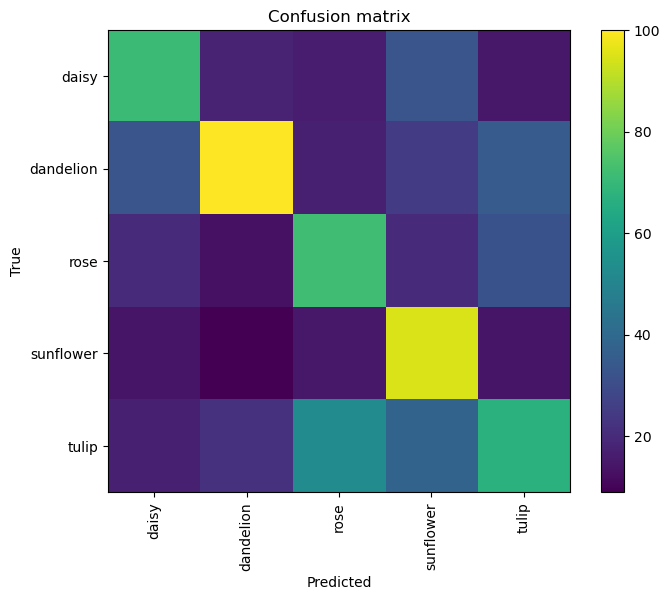

In [15]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
plt.imshow(cm, interpolation='nearest')
plt.title("Confusion matrix")
plt.colorbar()
plt.xticks(np.arange(len(classes)), classes, rotation=90)
plt.yticks(np.arange(len(classes)), classes)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()